# CNN

### (1) structure

[input] -> [convolution layer] -> [pooling layer] -> [fully connected layer] -> [output]

- convolution layer

    generate feature map by move kernel according to the stride and multiply some areas of the input data.

    (first layer: detect edgeline, color..)

    (second layer: texture, shape combination..)

    y = (w @ x.T + b)

- activation function

    relu = max(0, x)

- pooling layer

    summurize feature map with max or average ..
    (statical method) 

- fully connected layer

    flatten feature map previous layer and connected MLP structure.

    output = softmax(x)


### (2) data_processing

    list indexing

In [6]:
import numpy as np
import matplotlib.pyplot as plt
data_1 = np.load("./data/data1.npy")
data_2 = np.load("./data/data2.npy")
data_3 = np.load("./data/data3.npy")
data_4 = np.load("./data/data4.npy")

y1 = np.zeros(1000)
y2 = np.full(1000, 1)
y3 = np.full(1000, 2)
y4 = np.full(1000, 3)
labels = np.concatenate((y1, y2, y3, y4))

data_all = np.concatenate((data_1, data_2, data_3, data_4))

idx = np.random.permutation(len(data_all))

data_all = data_all[idx] #list indexing
labels = labels[idx]
labels = labels.astype(int)
print(data_all.shape)

(4000, 12, 12)


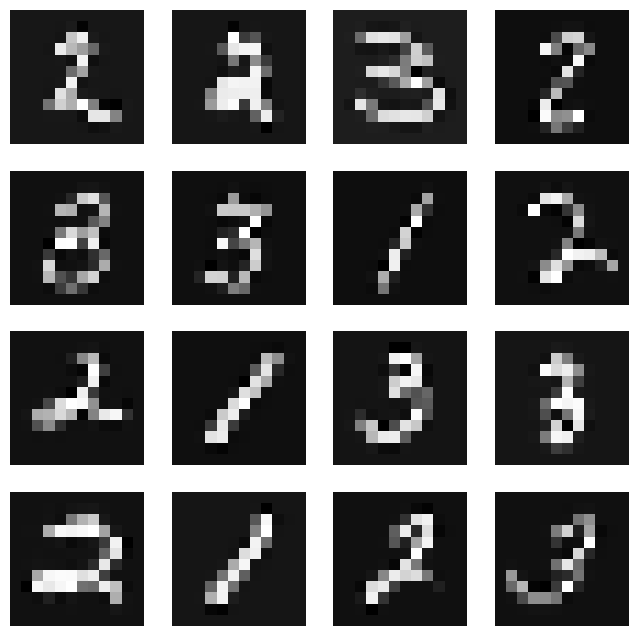

[1 1 2 1 2 2 0 1 1 0 2 2 1 0 1]


In [7]:
plt.figure(figsize = (8,8))
for i in range(16): #for i in range(num_image)
    plt.subplot(4, 4, i+1) #subplot(num_row, num_col, index)
    plt.imshow(data_all[i], cmap = 'gray')
    plt.axis('off')

plt.show()
print(labels[:15])

In [8]:
from model2 import *

x = np.expand_dims(data_all , axis = 1)
x = torch.tensor(x, dtype = torch.float32)
y = torch.tensor(labels, dtype = torch.long)
x_train = x[:300, :, :, :]
y_train = y[:300]
x.shape

torch.Size([4000, 1, 12, 12])

In [9]:
model = CNN(num_classes = 4)
with torch.no_grad():
    out = model.pool(model.conv3(model.conv2(model.conv1(x))))
    print(out.shape)



torch.Size([4000, 32, 3, 3])


In [10]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)
for epoch in range(1000):
  optimizer.zero_grad()
  outputs = model(x_train)
  loss = criterion(outputs , y_train)
  loss.backward()
  optimizer.step()

  if epoch % 10 == 0:
    print(f'Epoch [{epoch}/1000], Loss: {loss.item():.4f}')


Epoch [0/1000], Loss: 1.3895
Epoch [10/1000], Loss: 1.3877
Epoch [20/1000], Loss: 1.3862
Epoch [30/1000], Loss: 1.3847
Epoch [40/1000], Loss: 1.3833
Epoch [50/1000], Loss: 1.3820
Epoch [60/1000], Loss: 1.3807
Epoch [70/1000], Loss: 1.3795
Epoch [80/1000], Loss: 1.3784
Epoch [90/1000], Loss: 1.3773
Epoch [100/1000], Loss: 1.3763
Epoch [110/1000], Loss: 1.3752
Epoch [120/1000], Loss: 1.3742
Epoch [130/1000], Loss: 1.3732
Epoch [140/1000], Loss: 1.3722
Epoch [150/1000], Loss: 1.3713
Epoch [160/1000], Loss: 1.3703
Epoch [170/1000], Loss: 1.3694
Epoch [180/1000], Loss: 1.3684
Epoch [190/1000], Loss: 1.3674
Epoch [200/1000], Loss: 1.3664
Epoch [210/1000], Loss: 1.3654
Epoch [220/1000], Loss: 1.3645
Epoch [230/1000], Loss: 1.3634
Epoch [240/1000], Loss: 1.3624
Epoch [250/1000], Loss: 1.3613
Epoch [260/1000], Loss: 1.3602
Epoch [270/1000], Loss: 1.3591
Epoch [280/1000], Loss: 1.3579
Epoch [290/1000], Loss: 1.3566
Epoch [300/1000], Loss: 1.3553
Epoch [310/1000], Loss: 1.3539
Epoch [320/1000], L

In [11]:
x_test = x[101:201, :, :, :]
y_test = y[101:201]

model.eval()

with torch.no_grad():
    ouputs = model(x_test)

preds = torch.argmax(outputs, dim = 1)
print(preds)
print(y_test)

tensor([1, 1, 2, 2, 2, 2, 0, 1, 1, 0, 2, 2, 1, 0, 1, 2, 3, 1, 3, 2, 3, 1, 1, 1,
        2, 3, 3, 1, 3, 2, 3, 1, 0, 3, 3, 3, 0, 1, 2, 3, 0, 0, 3, 1, 3, 2, 0, 1,
        0, 3, 3, 2, 1, 0, 3, 0, 2, 2, 0, 1, 1, 2, 1, 1, 0, 1, 1, 3, 3, 3, 3, 3,
        3, 2, 2, 2, 2, 1, 0, 0, 3, 3, 1, 2, 2, 0, 0, 3, 2, 2, 1, 3, 0, 0, 0, 0,
        1, 3, 0, 2, 1, 3, 1, 0, 2, 2, 2, 1, 1, 1, 3, 3, 1, 1, 1, 1, 3, 1, 0, 0,
        1, 3, 2, 3, 1, 3, 3, 0, 1, 0, 1, 1, 1, 1, 1, 2, 1, 3, 2, 0, 1, 3, 0, 0,
        3, 2, 0, 1, 2, 3, 3, 1, 2, 2, 2, 3, 2, 0, 2, 2, 0, 1, 3, 2, 2, 0, 0, 2,
        0, 1, 0, 3, 0, 2, 1, 3, 2, 1, 2, 1, 2, 1, 2, 0, 1, 2, 3, 3, 2, 1, 1, 0,
        2, 2, 0, 3, 1, 1, 3, 2, 0, 3, 2, 0, 1, 1, 0, 3, 0, 3, 1, 0, 3, 0, 0, 2,
        3, 3, 1, 0, 3, 3, 0, 2, 2, 2, 3, 3, 1, 0, 1, 2, 1, 3, 0, 0, 1, 3, 1, 1,
        1, 1, 2, 3, 0, 1, 3, 3, 3, 3, 1, 0, 3, 2, 2, 1, 2, 0, 0, 2, 1, 1, 1, 0,
        2, 2, 3, 3, 2, 1, 3, 0, 1, 1, 0, 0, 0, 3, 2, 3, 3, 2, 3, 2, 3, 3, 2, 2,
        2, 1, 0, 1, 1, 0, 0, 0, 3, 2, 2,